probeA = AM, probeB = PM, probeC = V1, probeD = LM, probeE = AL, probeF = RL

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [307]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
sns.set_theme()

In [3]:
import pickle
with open('membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [5]:
# Load LFP data
start_time = 0.0
end_time = 0.50
padding = 0.1
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeC','probeD','probeE'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

D:\Anaconda3\lib\site-packages\allensdk\brain_observatory\comparison_utils.py:9: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  from pandas.util.testing import assert_frame_equal


Download time: 1200


D:\Anaconda3\lib\site-packages\allensdk\brain_observatory\ecephys\stimulus_table\naming_utilities.py:146: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
D:\Anaconda3\lib\site-packages\allensdk\brain_observatory\ecephys\ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


# Test kernel smoothing of instantaneous speed

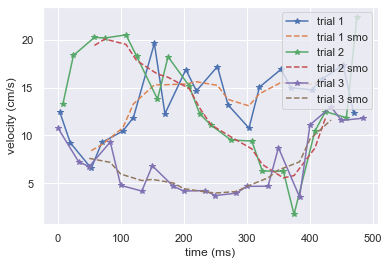

In [23]:
all_time = V1._session.running_speed['mean_time']
all_v = V1._session.running_speed['velocity']
time_list = [1586.1, 1592.1, 1622.1]
for time in time_list:
    idx = (all_time<time+0.5) & (all_time>time)
    plt.plot((all_time[idx]-time)*1000,all_v[idx] , '-*')
    temp = all_v[idx]
    hrly = pd.Series(temp)
    smooth = hrly.rolling(window=5, win_type='gaussian', center=True).mean(std=1)
    plt.plot((all_time[idx]-time)*1000, smooth , '--')
plt.xlabel('time (ms)')
plt.ylabel('velocity (cm/s)')
plt.legend(('trial 1', 'trial 1 smo', 'trial 2', 'trial 2 smo', 'trial 3', 'trial 3 smo',))

# Unit test on 'PP_GLM' class and 'plot_GLM_compare' function

In [88]:
results_list = []

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=15)
model.add_effect('coupling', 'probeD', peaks_max=150, num=5, nonlinear=0.2 )
model.add_effect('coupling', 'probeE', peaks_max=150, num=5, nonlinear=0.2 )
model.add_effect('twoway_coupling', V1.speed[:,select_trials], peaks_max=100, num=3, nonlinear=0.4)
results_list.append(model.fit('probeC'))

select_trials = V1.stationary_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=15)
model.add_effect('coupling', 'probeD', peaks_max=150, num=5, nonlinear=0.2 )
model.add_effect('coupling', 'probeE', peaks_max=150, num=5, nonlinear=0.2 )
model.add_effect('twoway_coupling', V1.speed[:,select_trials], peaks_max=100, num=3, nonlinear=0.4)
results_list.append(model.fit('probeC'))

label_list = ['running', 'stationary']

Assuming raw inputs are spike trains from probeD
Assuming raw inputs are spike trains from probeE
Assuming raw inputs are spike trains from probeC
Negative log likelihood is: 30525.20
Assuming raw inputs are spike trains from probeD
Assuming raw inputs are spike trains from probeE
Assuming raw inputs are spike trains from probeC
Negative log likelihood is: 49866.02


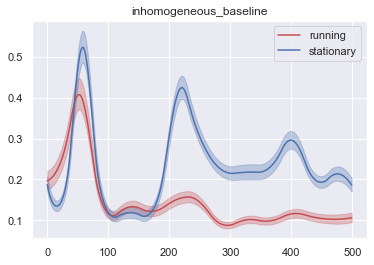

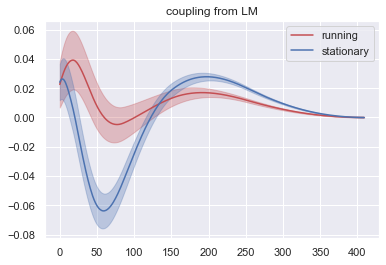

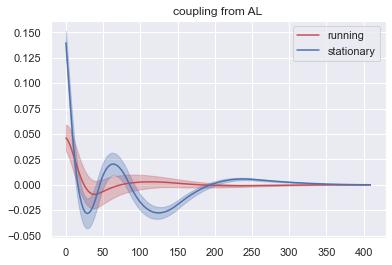

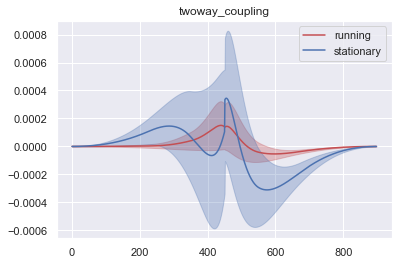

In [85]:
GLM.plot_GLM_compare(model, results_list=results_list, label_list=label_list)

# Model the effect of speed in running trials in different ways

## Without speed

Assuming raw inputs are spike trains from probeD
Assuming raw inputs are spike trains from probeE
Assuming raw inputs are spike trains from probeC
Negative log likelihood is: 28054.65
aic/2 is: 28080.65


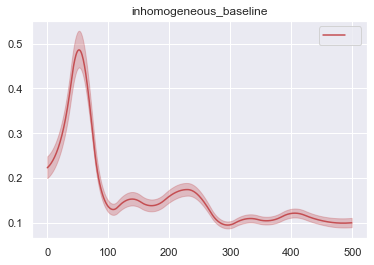

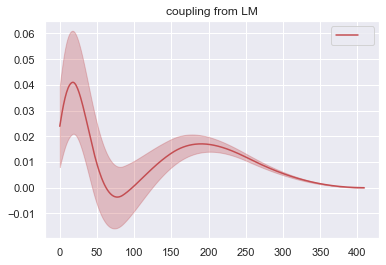

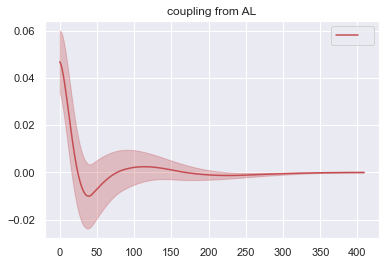

In [195]:
select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=15)
model.add_effect('coupling', 'probeD', peaks_max=150, num=5, nonlinear=0.2 )
model.add_effect('coupling', 'probeE', peaks_max=150, num=5, nonlinear=0.2 )
# model.add_effect('twoway_coupling', V1.speed[:,select_trials], peaks_max=100, num=3, nonlinear=0.4)
results_list.append(model.fit('probeC'))
GLM.plot_GLM_compare(model)

## Two way coupling

Assuming raw inputs are spike trains from probeD
Assuming raw inputs are spike trains from probeE
Assuming raw inputs are spike trains from probeC
Negative log likelihood is: 28017.97
aic/2 is: 28048.97


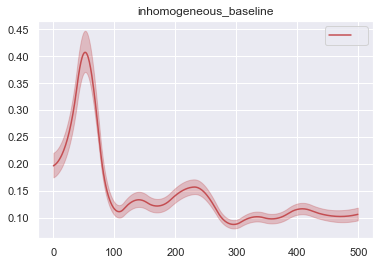

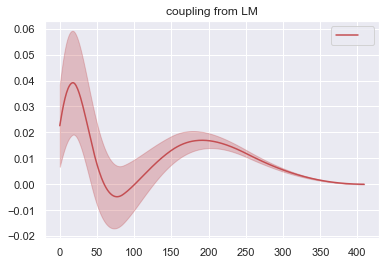

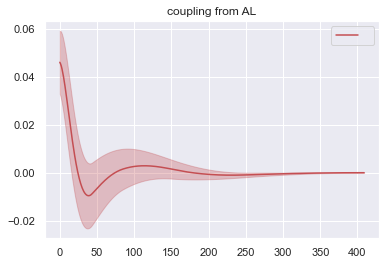

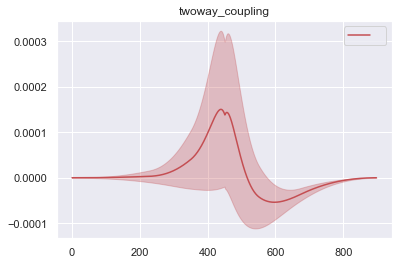

In [192]:
select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=15)
model.add_effect('coupling', 'probeD', peaks_max=150, num=5, nonlinear=0.2 )
model.add_effect('coupling', 'probeE', peaks_max=150, num=5, nonlinear=0.2 )
model.add_effect('twoway_coupling', V1.speed[:,select_trials], peaks_max=100, num=3, nonlinear=0.4)
results_list.append(model.fit('probeC'))
GLM.plot_GLM_compare(model)

## Linear term (stationary coefficient)

Assuming raw inputs are spike trains from probeD
Assuming raw inputs are spike trains from probeE
Assuming raw inputs are spike trains from probeC
Negative log likelihood is: 28054.56
aic/2 is: 28081.56


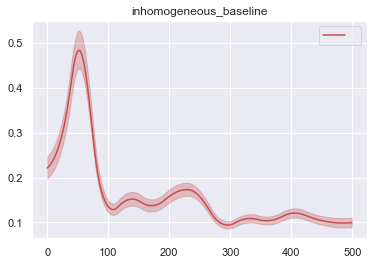

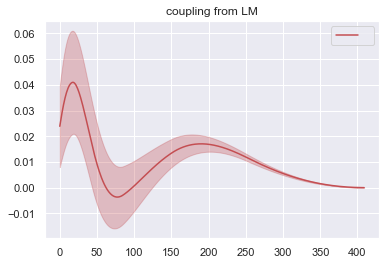

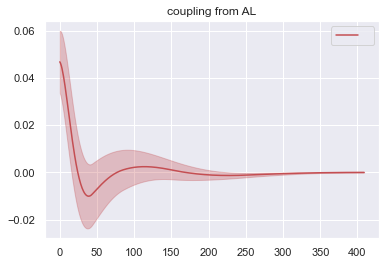

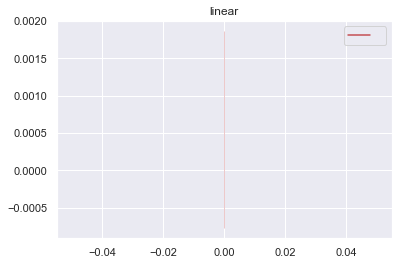

In [191]:
select_trials = V1.running_trial_index
# select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=15)
model.add_effect('coupling', 'probeD', peaks_max=150, num=5, nonlinear=0.2 )
model.add_effect('coupling', 'probeE', peaks_max=150, num=5, nonlinear=0.2 )
model.add_effect('linear', V1.speed[:,select_trials])
model.fit('probeC')
GLM.plot_GLM_compare(model)

## Non-stationary coefficient (a function of time)

Negative log likelihood is: 27799.01
aic/2 is: 27861.01


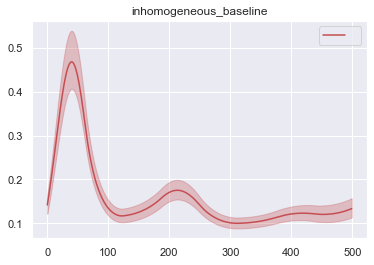

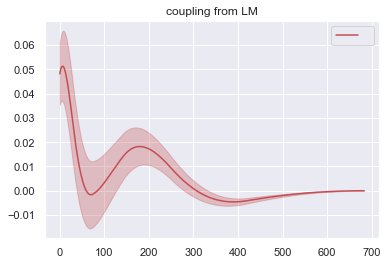

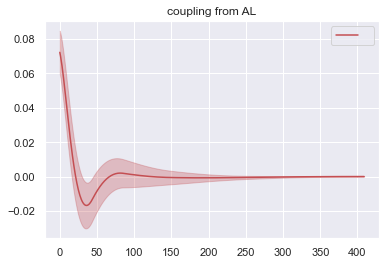

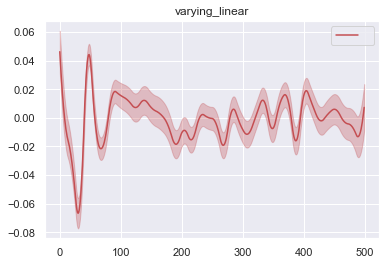

In [200]:
select_trials = V1.running_trial_index
# select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=10)
model.add_effect('coupling', 'probeD', peaks_max=250, num=5, nonlinear=0.2 )
model.add_effect('coupling', 'probeE', peaks_max=150, num=5, nonlinear=0.2 )
model.add_effect('varying_linear', V1.speed[:,select_trials], num=40)
model.fit('probeC')
GLM.plot_GLM_compare(model)

Therefore, time varying linear coefficient seems to fit best. 

# Hyperparameter tuning

# Discover lead or lag

In [201]:
# Just to get a wider range of speed
start_time = -0.5
end_time = 1.0
padding = 0.1
V1_wider = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeC','probeD','probeE'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

V1_wider.get_running(method="mine")

Download time: 1200


D:\Anaconda3\lib\site-packages\allensdk\brain_observatory\ecephys\stimulus_table\naming_utilities.py:146: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)


In [202]:
V1_wider.speed.shape

(1500, 210)

In [446]:
time_diff_list = np.arange(-400, 401, 20)
nrep = 1
nlogli_rcd = np.zeros((len(time_diff_list),nrep))
for i, time_diff in enumerate(tqdm(time_diff_list)):
    for irep in range(nrep):
        
        bt_origin_set_idx = np.where(V1.running_trial_index)[0]
        bt_sample_set_idx = np.random.choice(bt_origin_set_idx, 
                                             size=len(bt_origin_set_idx), 
                                             replace=False)
        select_trials = np.full(V1.ntrial, False)
        select_trials[bt_sample_set_idx] = True
        # select_trials = np.full(V1.ntrial, True)

        model = GLM.PP_GLM(dataset=V1, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model.add_effect('inhomogeneous_baseline', num=30)
        model.add_effect('coupling', 'probeD', peaks_max=250, num=5, nonlinear=0.2 )
        model.add_effect('coupling', 'probeE', peaks_max=150, num=5, nonlinear=0.2 )
        model.add_effect('varying_linear', V1_wider.speed[(500+time_diff):(1000+time_diff),select_trials], num=30)
        model.fit('probeC', verbose=False)
        nlogli_rcd[i, irep] = model.nlogli


100%|███████████████████████████████████████████████████████████████████| 41/41 [03:20<00:00,  4.89s/it]


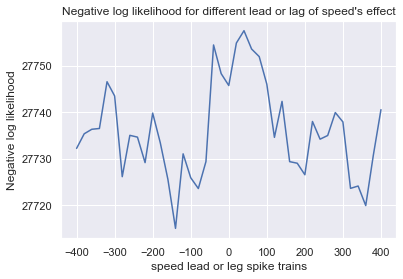

In [447]:
# Error bar plot
x = time_diff_list
y = nlogli_rcd.mean(axis=1)
dy = nlogli_rcd.std(axis=1)/np.sqrt(nrep)

plt.figure()
plt.errorbar(x, y, yerr=dy)
plt.title(f"Negative log likelihood for different lead or lag of speed's effect")
plt.xlabel(f"speed lead or leg spike trains")
plt.ylabel(f"Negative log likelihood")
plt.show()

In [368]:
time_diff_list = np.arange(-450, 451, 100)
nrep = 10
nlogli_rcd = np.zeros((len(time_diff_list),nrep))
for irep in tqdm(range(nrep)):
    bt_origin_set_idx = np.where(V1.running_trial_index)[0]
    bt_sample_set_idx = np.random.choice(bt_origin_set_idx, 
                                         size=len(bt_origin_set_idx), 
                                         replace=True)
    select_trials = np.full(V1.ntrial, False)
    select_trials[bt_sample_set_idx] = True
    for i, time_diff in enumerate(time_diff_list):
        model = GLM.PP_GLM(dataset=V1, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model.add_effect('inhomogeneous_baseline', num=10)
        model.add_effect('coupling', 'probeD', peaks_max=250, num=5, nonlinear=0.2 )
        model.add_effect('coupling', 'probeE', peaks_max=150, num=5, nonlinear=0.2 )
        model.add_effect('varying_linear', V1_wider.speed[(500+time_diff):(1000+time_diff),select_trials], num=20)
        model.fit('probeC', verbose=False)
        nlogli_rcd[i, irep] = model.nlogli


100%|███████████████████████████████████████████████████████████████████| 10/10 [03:13<00:00, 19.35s/it]


In [ ]:
# Error bar plot
x = time_diff_list
y = nlogli_rcd.mean(axis=1)
dy = nlogli_rcd.std(axis=1)/np.sqrt(nrep)

plt.figure()
plt.errorbar(x, y, yerr=dy)
plt.title(f"Negative log likelihood for different lead or lag of speed's effect")
plt.xlabel(f"speed lead or leg spike trains")
plt.ylabel(f"Negative log likelihood difference")
plt.show()

In [ ]:
# Error bar plot but paired
best_id = np.argmin(nlogli_rcd.mean(axis=1))
x = time_diff_list
y = (nlogli_rcd-nlogli_rcd[best_id,:]).mean(axis=1)
dy = (nlogli_rcd-nlogli_rcd[best_id,:]).std(axis=1)/np.sqrt(nrep)

plt.figure()
plt.errorbar(x, y, yerr=dy)
plt.title(f"Negative log likelihood for different lead or lag of speed's effect")
plt.xlabel(f"speed lead or leg spike trains")
plt.ylabel(f"Negative log likelihood difference")
plt.show()

# Discover smoothing

In [539]:
##### changing smooth_std
n_cv = 10
changing_param_list = np.logspace(0, 2.3, 10)
best_time_diff = 0
all_considered_trial_idx = np.where(V1.running_trial_index)[0]

##### 
nlogli_rcd = np.zeros((len(changing_param_list), n_cv))
template_for_kf = np.zeros((len(all_considered_trial_idx),1))

from sklearn.model_selection import KFold
kf = KFold(n_splits=n_cv)
kf.get_n_splits(template_for_kf)

for i, smooth_std in enumerate(tqdm(changing_param_list)):
    j = 0
    for train_index, test_index in kf.split(template_for_kf):
        select_trials = np.full(V1.ntrial, False)
        select_trials[all_considered_trial_idx[train_index]] = True
        test_trials = np.full(V1.ntrial, False)
        test_trials[all_considered_trial_idx[test_index]] = True

        model = GLM.PP_GLM(dataset=V1, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model.add_effect('inhomogeneous_baseline', num=10)
        model.add_effect('coupling', 'probeD', peaks_max=250, num=5, nonlinear=0.2 )
        model.add_effect('coupling', 'probeE', peaks_max=150, num=5, nonlinear=0.2 )
        smo = utils.kernel_smoothing(V1_wider.speed, 
                                     smooth_std)[(500+best_time_diff):(1000+best_time_diff),:]
        model.add_effect('varying_linear', smo, num=num_varying_linear)
        model.fit('probeC', verbose=False)

        nlogli_rcd[i, j] = model.test(test_trials)
        j += 1

100%|█████████████████████████████████████████████████████████████████████| 3/3 [01:04<00:00, 21.61s/it]


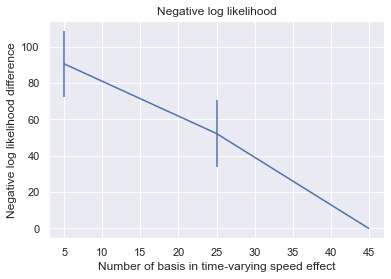

In [540]:
best_id = np.argmin(nlogli_rcd.mean(axis=1))
x = num_varying_linear_list
y = (nlogli_rcd-nlogli_rcd[best_id,:]).mean(axis=1)
dy = 2*(nlogli_rcd-nlogli_rcd[best_id,:]).std(axis=1)/np.sqrt(nlogli_rcd.shape[1])

plt.figure()
plt.errorbar(x, y, yerr=dy)
plt.title(f"Negative log likelihood")
plt.xlabel(f"Number of basis in time-varying speed effect")
plt.ylabel(f"Negative log likelihood difference")
plt.show()

Abondon the next two

In [450]:
smooth_std_list = np.logspace(0, 2.3, 10)
best_time_diff = 0
nrep = 1
nlogli_rcd = np.zeros((len(smooth_std_list),nrep))
for i, smooth_std in enumerate(tqdm(smooth_std_list)):
    for irep in range(nrep):
        bt_origin_set_idx = np.where(V1.running_trial_index)[0]
        bt_sample_set_idx = np.random.choice(bt_origin_set_idx, 
                                             size=len(bt_origin_set_idx), 
                                             replace=False)
        select_trials = np.full(V1.ntrial, False)
        select_trials[bt_sample_set_idx] = True
        # select_trials = np.full(V1.ntrial, True)

        model = GLM.PP_GLM(dataset=V1, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model.add_effect('inhomogeneous_baseline', num=30)
        model.add_effect('coupling', 'probeD', peaks_max=250, num=5, nonlinear=0.2 )
        model.add_effect('coupling', 'probeE', peaks_max=150, num=5, nonlinear=0.2 )
        smo = utils.kernel_smoothing(V1_wider.speed, 
                                     smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
        model.add_effect('varying_linear', smo, num=10)
        model.fit('probeC', verbose=False)
        nlogli_rcd[i, irep] = model.nlogli

100%|███████████████████████████████████████████████████████████████████| 10/10 [00:34<00:00,  3.40s/it]


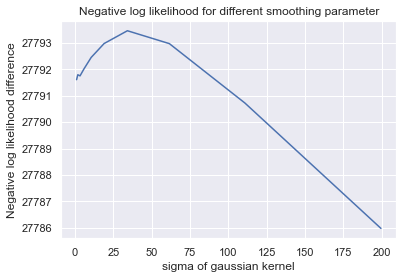

In [451]:
# Error bar plot
x = smooth_std_list
y = nlogli_rcd.mean(axis=1)
dy = nlogli_rcd.std(axis=1)/np.sqrt(nrep)

plt.figure()
plt.errorbar(x, y, yerr=dy)
plt.title(f"Negative log likelihood for different smoothing parameter")
plt.xlabel(f"sigma of gaussian kernel")
plt.ylabel(f"Negative log likelihood difference")
plt.show()

# Number of basis for baseline

In [ ]:
##### Cell for CV
n_cv = 10
para_list = np.arange(5,50,2)
all_considered_trial_idx = np.where(V1.running_trial_index)[0]

##### Other parameters
best_time_diff = 0
smooth_std = 1
num_basis_baseline = 30
num_varying_linear = 10

##### 
nlogli_rcd = np.zeros((len(para_list), n_cv))
template_for_kf = np.zeros((len(all_considered_trial_idx),1))

from sklearn.model_selection import KFold
kf = KFold(n_splits=n_cv)
kf.get_n_splits(template_for_kf)

for i, num_basis_baseline in enumerate(tqdm(para_list)):
    j = 0
    for train_index, test_index in kf.split(template_for_kf):
        select_trials = np.full(V1.ntrial, False)
        select_trials[all_considered_trial_idx[train_index]] = True
        test_trials = np.full(V1.ntrial, False)
        test_trials[all_considered_trial_idx[test_index]] = True

        model = GLM.PP_GLM(dataset=V1, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
        model.add_effect('coupling', 'probeD', peaks_max=250, num=5, nonlinear=0.2 )
        model.add_effect('coupling', 'probeE', peaks_max=150, num=5, nonlinear=0.2 )
        smo = utils.kernel_smoothing(V1_wider.speed, 
                                     smooth_std)[(500+best_time_diff):(1000+best_time_diff),:]
        model.add_effect('varying_linear', smo, num=num_varying_linear)
        model.fit('probeC', verbose=False)

        nlogli_rcd[i, j] = model.test(test_trials)
        j += 1

  0%|                                                                            | 0/23 [00:00<?, ?it/s]

In [ ]:
best_id = np.argmin(nlogli_rcd.mean(axis=1))
x = num_varying_linear_list
y = (nlogli_rcd-nlogli_rcd[best_id,:]).mean(axis=1)
dy = 2*(nlogli_rcd-nlogli_rcd[best_id,:]).std(axis=1)/np.sqrt(nlogli_rcd.shape[1])

plt.figure()
plt.errorbar(x, y, yerr=dy)
plt.title(f"Negative log likelihood")
plt.xlabel(f"Number of basis in time-varying speed effect")
plt.ylabel(f"Negative log likelihood difference")
plt.show()

# Number of basis for time-varying coefficient of speed

In [544]:
##### Cell for CV
n_cv = 10
para_list = np.arange(5,50,2)
all_considered_trial_idx = np.where(V1.running_trial_index)[0]

##### Other parameters
best_time_diff = 0
smooth_std = 1
num_basis_baseline = 30

##### 
nlogli_rcd = np.zeros((len(para_list), n_cv))
template_for_kf = np.zeros((len(all_considered_trial_idx),1))

from sklearn.model_selection import KFold
kf = KFold(n_splits=n_cv)
kf.get_n_splits(template_for_kf)

for i, num_varying_linear in enumerate(tqdm(para_list)):
    j = 0
    for train_index, test_index in kf.split(template_for_kf):
        select_trials = np.full(V1.ntrial, False)
        select_trials[all_considered_trial_idx[train_index]] = True
        test_trials = np.full(V1.ntrial, False)
        test_trials[all_considered_trial_idx[test_index]] = True

        model = GLM.PP_GLM(dataset=V1, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
        model.add_effect('coupling', 'probeD', peaks_max=250, num=5, nonlinear=0.2 )
        model.add_effect('coupling', 'probeE', peaks_max=150, num=5, nonlinear=0.2 )
        smo = utils.kernel_smoothing(V1_wider.speed, 
                                     smooth_std)[(500+best_time_diff):(1000+best_time_diff),:]
        model.add_effect('varying_linear', smo, num=num_varying_linear)
        model.fit('probeC', verbose=False)

        nlogli_rcd[i, j] = model.test(test_trials)
        j += 1

  0%|                                                                            | 0/23 [00:07<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
best_id = np.argmin(nlogli_rcd.mean(axis=1))
x = num_varying_linear_list
y = (nlogli_rcd-nlogli_rcd[best_id,:]).mean(axis=1)
dy = 2*(nlogli_rcd-nlogli_rcd[best_id,:]).std(axis=1)/np.sqrt(nlogli_rcd.shape[1])

plt.figure()
plt.errorbar(x, y, yerr=dy)
plt.title(f"Negative log likelihood")
plt.xlabel(f"Number of basis in time-varying speed effect")
plt.ylabel(f"Negative log likelihood difference")
plt.show()

# Plot best model

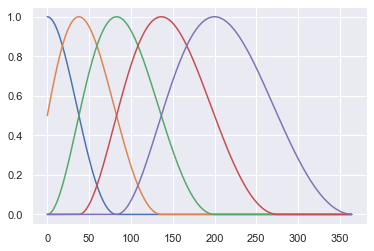

Negative log likelihood is: 27721.81
aic/2 is: 27773.81


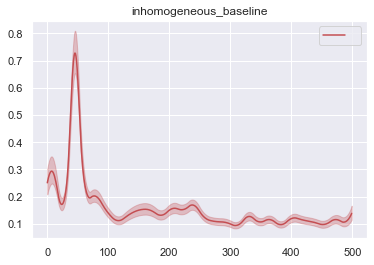

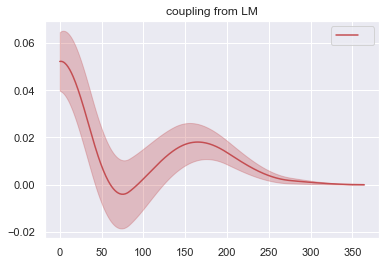

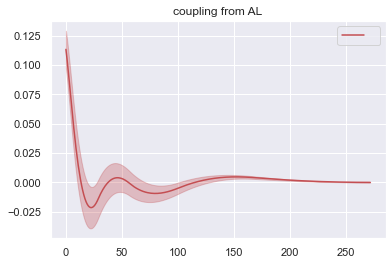

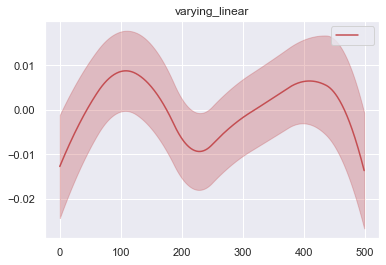

In [509]:
best_time_diff = 0
smooth_std = 1

select_trials = V1.running_trial_index

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=30)
model.add_effect('coupling', 'probeD', peaks_max=200, num=5, nonlinear=1, verbose=True)
model.add_effect('coupling', 'probeE', peaks_max=100, num=5, nonlinear=0.2)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('varying_linear', smo, num=10)
model.fit('probeC', verbose=True)
GLM.plot_GLM_compare(model)

Negative log likelihood is: 27828.48
aic/2 is: 27878.48


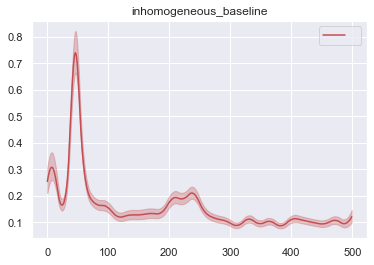

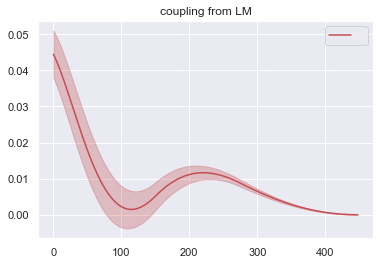

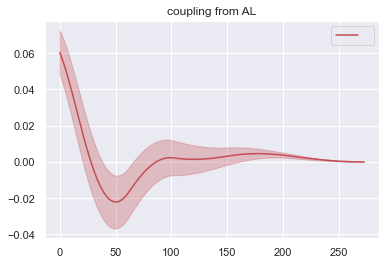

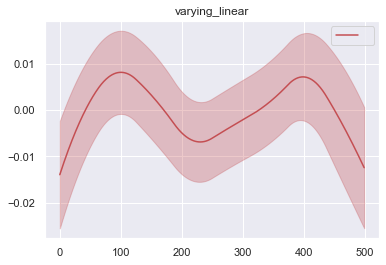

In [494]:
best_time_diff = 0
smooth_std = 1

select_trials = V1.running_trial_index

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=30)
model.add_effect('coupling', 'probeD', peaks_max=150, num=3, nonlinear=1)
model.add_effect('coupling', 'probeE', peaks_max=150, num=5, nonlinear=1 )
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('varying_linear', smo, num=10)
model.fit('probeC', verbose=True)
GLM.plot_GLM_compare(model)